# 1. Primeros Pasos con PA3Py

En este notebook aprenderemos a inicializar `PA3Py`, correr una simulación de crecimiento para un embrión y graficar los resultados.

In [6]:
import sys
import os
import matplotlib.pyplot as plt

# Agregar la ruta del paquete (si corres desde el repositorio local)
sys.path.insert(0, os.path.abspath('../../src'))
from pa3py import PA3Py

## Inicializando la Simulación

Cargamos la simulación simplemente pasando la ruta de nuestro disco HDF5 a la clase principal `PA3Py`.

In [7]:
# Ruta a tus datos HDF5 de TripodPy
data_path = '../../tests/test_data/run_smooth_a0.001_v10'

# Inicializamos el motor
sim = PA3Py(data_path)

[load_tripodpy_hdf5] Leyendo 100 snapshots desde ../../tests/test_data/run_smooth_a0.001_v10...


## Corriendo el Crecimiento

Le diremos a `PA3Py` que corra el crecimiento para un embrión ubicado a 5 AU, con una masa inicial semilla de $10^{-3} M_\oplus$.

In [8]:
# Embriones a correr
embriones = [3.0]

# Ejecutamos el módulo
resultados = sim.run_growth(embriones, m_seed_me=1e-3)


-------------------------------------------------------------
  r [AU]  M_tot [ME]  M_iso [ME]  f_silicates[%]  f_H2O[%]
-------------------------------------------------------------
    3.00        9.016         9.02            50.0      50.0
-------------------------------------------------------------



## Graficando la Evolución de Masa

El diccionario `resultados` contiene matrices donde la primera columna es el tiempo (en segundos) y la segunda es la masa total del embrión.

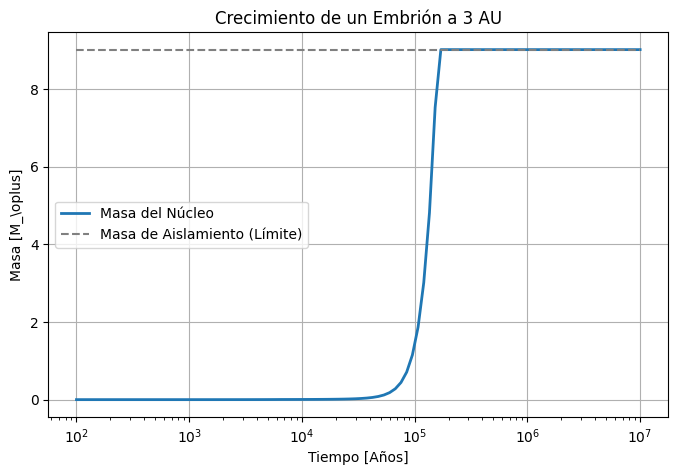

In [11]:
# Extraemos los datos del embrión en 5 AU
historia_3au = resultados[3.0]

tiempo_años = historia_3au[:, 0] / (3.154e7)  # Convertir s a años
masa_total = historia_3au[:, 1] / sim.engine.M_EARTH # Convertir a Masas Terrestres
masa_iso = historia_3au[:, 2] / sim.engine.M_EARTH


plt.figure(figsize=(8,5))
plt.plot(tiempo_años, masa_total, lw=2, label="Masa del Núcleo")
plt.plot(tiempo_años, masa_iso, '--', color='gray', label="Masa de Aislamiento (Límite)")
plt.xlabel("Tiempo [Años]")
plt.ylabel("Masa [M_\oplus]")
plt.xscale("log")
plt.title("Crecimiento de un Embrión a 3 AU")
plt.legend()
plt.grid(True)
plt.show()

## Fracción de Agua

Por defecto, PA3Py corre el modelo clásico `silicates` y `H2O` midiendo la posición de la snowline.
Podemos extraer la masa de agua (columna 4) y ver cómo subió la fracción.

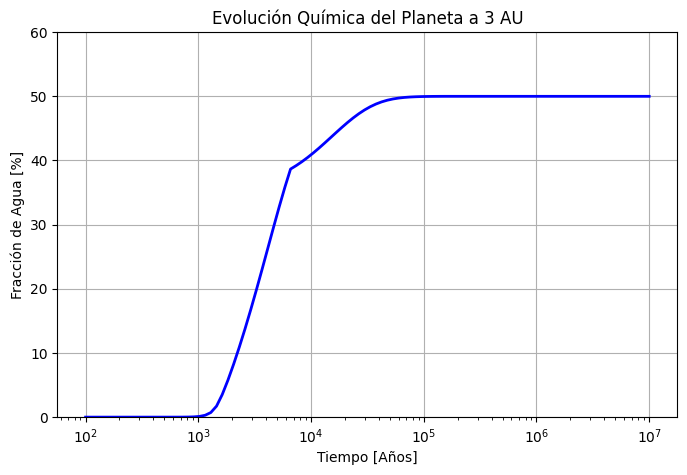

In [12]:
masa_silicatos = historia_3au[:, 3]
masa_agua = historia_3au[:, 4]
masa_suma = masa_silicatos + masa_agua

fraccion_agua = 100 * masa_agua / masa_suma

plt.figure(figsize=(8,5))
plt.plot(tiempo_años, fraccion_agua, color='blue', lw=2)
plt.xscale("log")
plt.xlabel("Tiempo [Años]")
plt.ylabel("Fracción de Agua [%]")
plt.title("Evolución Química del Planeta a 3 AU")
plt.ylim(0, 60)
plt.grid(True)
plt.show()